# 03 — 基金与南华商品指数匹配分析

本 Notebook 将每只私募基金净值与南华商品指数按共同日期对齐、以共同起点归一化，并按 02 使用的 90 日指标（每月按 30 天计）、三年阈值和六个月线性 ramp-in 板块状态统计条件收益。产品按配置分为截面和趋势两类，仅用于组织展示，不构造类别组合。历史不足区间不参与图表和绩效统计。

品种范围由板块映射确定，月均价衍生合约 L_F、PP_F、V_F 显式排除。同名旧新代码先分别计算对数收益，再对当日有效收益取均值，作为一个经济品种参与观测门槛、六个月 ramp-in 和板块内等权；不拼接价格，不填充缺失收益。

## 统计口径

- 基金与南华商品指数仅使用共同日期，图中两条曲线按共同首日归一化为 1。
- 市场状态只使用已经完成月份的月末指标。
- 只统计四种有效市场状态，历史不足区间不进入图表和绩效表。
- 基金和南华商品指数使用同一个共同日期年化因子：日频 252、周频 52、月频 12，更低频按自然日间隔折算。
- 非连续净值区间收益归入区间结束日对应的市场状态，跨状态区间不拆分。
- 产品类别由 config.yaml 的 fund_categories 按匿名基金编号维护；本 Notebook 不根据净值表现推断类别。

In [1]:
# ruff: noqa: E402, E501
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "config" / "config.yaml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, Markdown, display

import cta_research
from cta_research import (
    REGIME_LABELS,
    build_sector_research_context,
    compute_regime_annualized_returns,
    load_fund_histories,
    plot_fund_vs_nhci,
)

assert Path(cta_research.__file__).resolve().is_relative_to((PROJECT_ROOT / "src").resolve())
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["PingFang SC", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

In [2]:
context = build_sector_research_context(PROJECT_ROOT / "config" / "config.yaml", PROJECT_ROOT)
config = context.config
fund_categories = config["fund_categories"]
external_nhci = config["paths"].get("external_nhci_file")
nhci_path = PROJECT_ROOT / external_nhci if external_nhci else PROJECT_ROOT / config["paths"]["nhci"]
funds = load_fund_histories(context.raw_dir, exclude_paths=[nhci_path], fund_categories=fund_categories)
display(funds.manifest)
if funds.nav.empty:
    raise ValueError("No valid fund NAV workbook was found in data/.")

,status,reason,fund,category,start_date,end_date,observations
0,excluded,configured non-fund input,NaN,NaN,NaT,NaT,NaN
1,accepted,NaN,基金 01,趋势,2025-04-22,2026-07-31,311.0
2,accepted,NaN,基金 02,截面,2019-07-29,2026-07-31,394.0
3,accepted,NaN,基金 03,趋势,2024-01-05,2026-07-24,133.0
4,accepted,NaN,基金 04,截面,2017-03-01,2026-07-31,1605.0
5,accepted,NaN,基金 05,截面,2023-01-05,2026-07-24,199.0
6,accepted,NaN,基金 06,趋势,2017-02-17,2026-07-24,484.0


## 截面类产品

### 基金 02

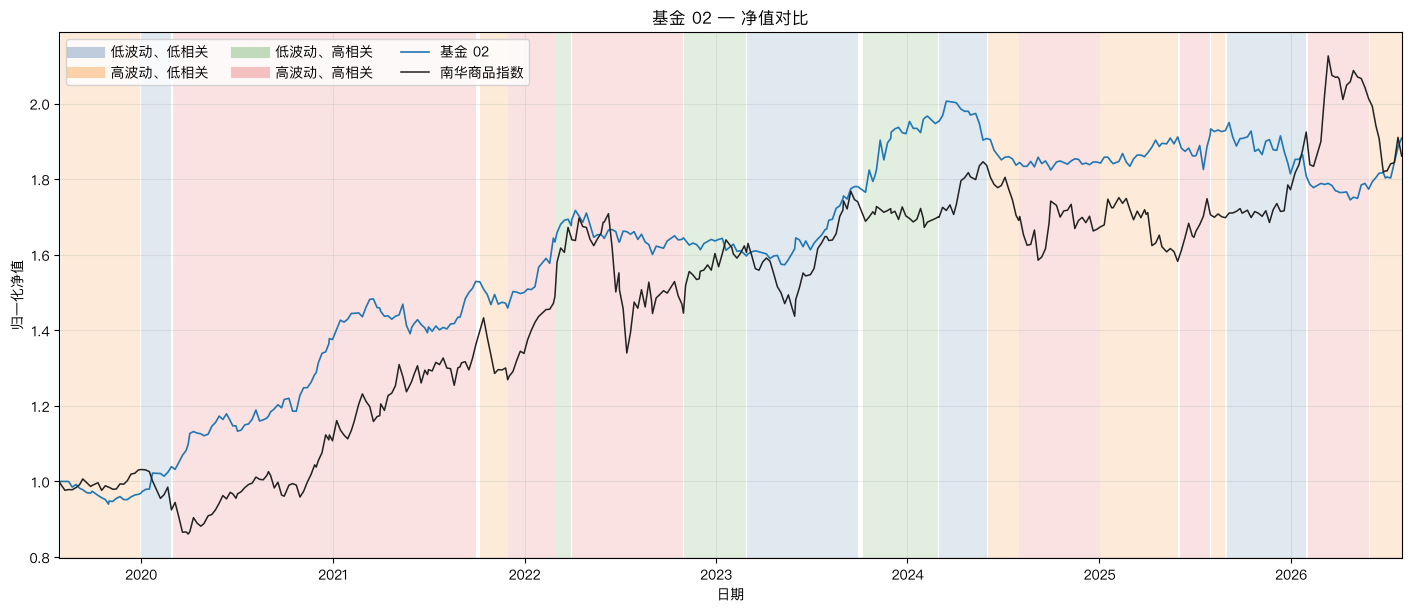

,南华商品指数 年化收益,南华商品指数 夏普,基金 02 年化收益,基金 02 夏普
低波动、低相关,12.29%,0.98,6.32%,0.76
高波动、低相关,-15.47%,-1.36,0.04%,0.04
低波动、高相关,22.27%,1.61,10.35%,1.15
高波动、高相关,15.60%,0.95,13.73%,1.56


### 基金 04

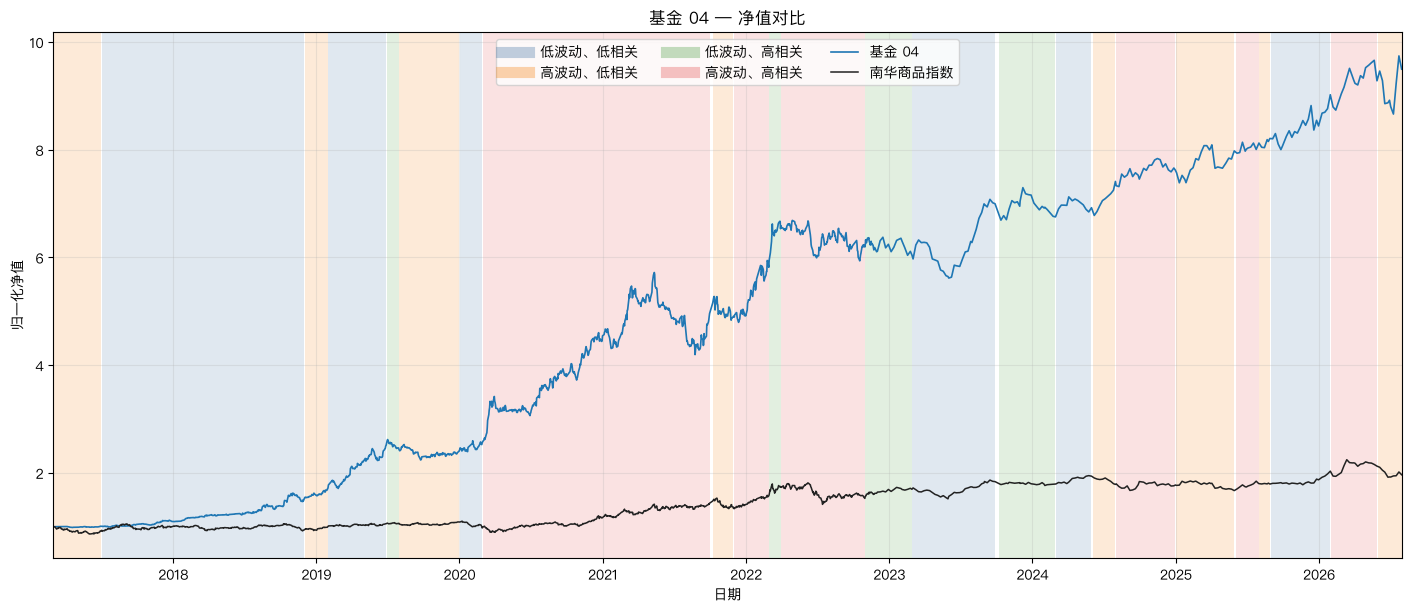

,南华商品指数 年化收益,南华商品指数 夏普,基金 04 年化收益,基金 04 夏普
低波动、低相关,11.62%,0.79,65.65%,2.90
高波动、低相关,-20.48%,-1.25,24.83%,1.33
低波动、高相关,58.10%,2.19,8.33%,0.47
高波动、高相关,23.41%,1.14,39.41%,1.67


### 基金 05

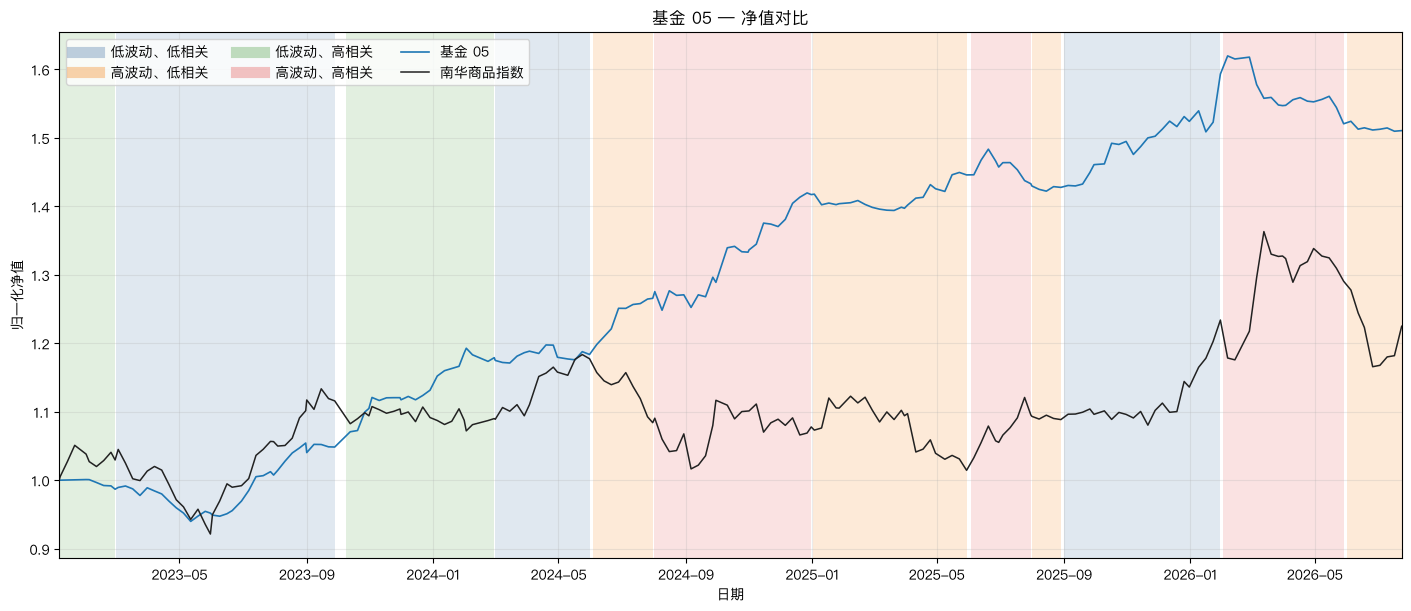

,南华商品指数 年化收益,南华商品指数 夏普,基金 05 年化收益,基金 05 夏普
低波动、低相关,23.39%,1.97,13.82%,1.86
高波动、低相关,-20.80%,-1.86,9.27%,1.99
低波动、高相关,0.94%,0.15,18.44%,2.92
高波动、高相关,12.54%,0.81,6.03%,0.74


## 趋势类产品

### 基金 01

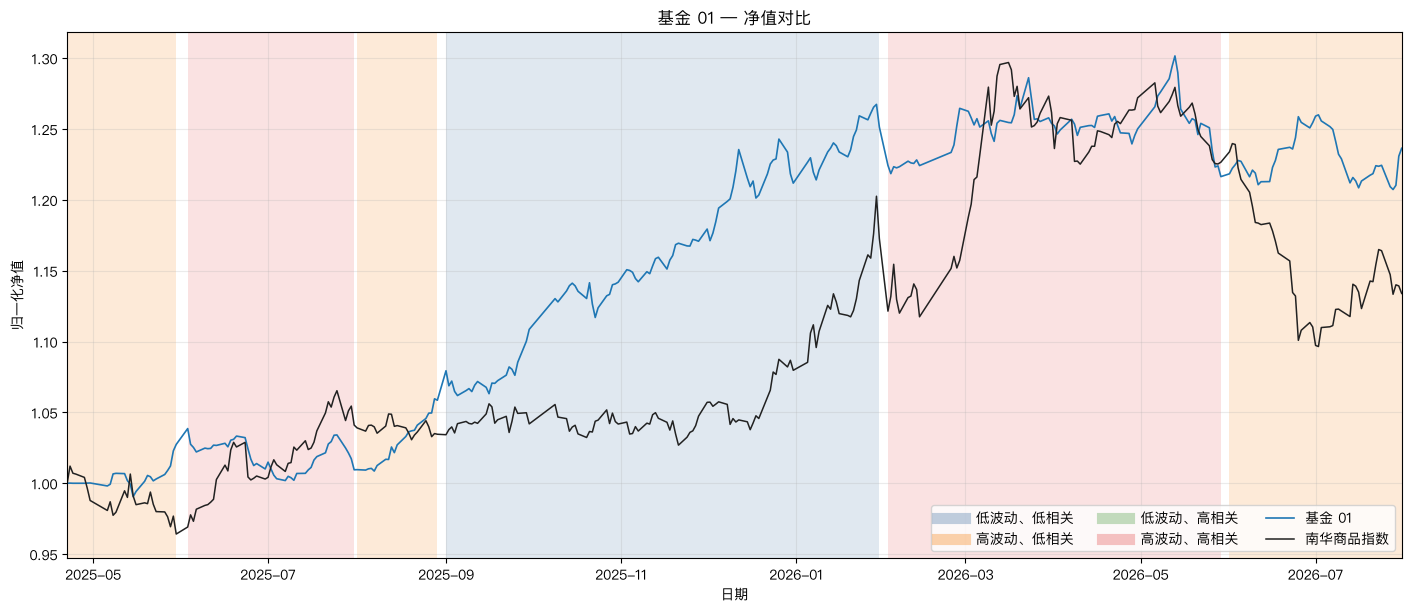

,南华商品指数 年化收益,南华商品指数 夏普,基金 01 年化收益,基金 01 夏普
低波动、低相关,36.30%,2.69,51.19%,4.04
高波动、低相关,-28.79%,-2.61,28.96%,3.37
低波动、高相关,nan%,nan,nan%,nan
高波动、高相关,29.66%,1.60,-9.35%,-0.98


### 基金 03

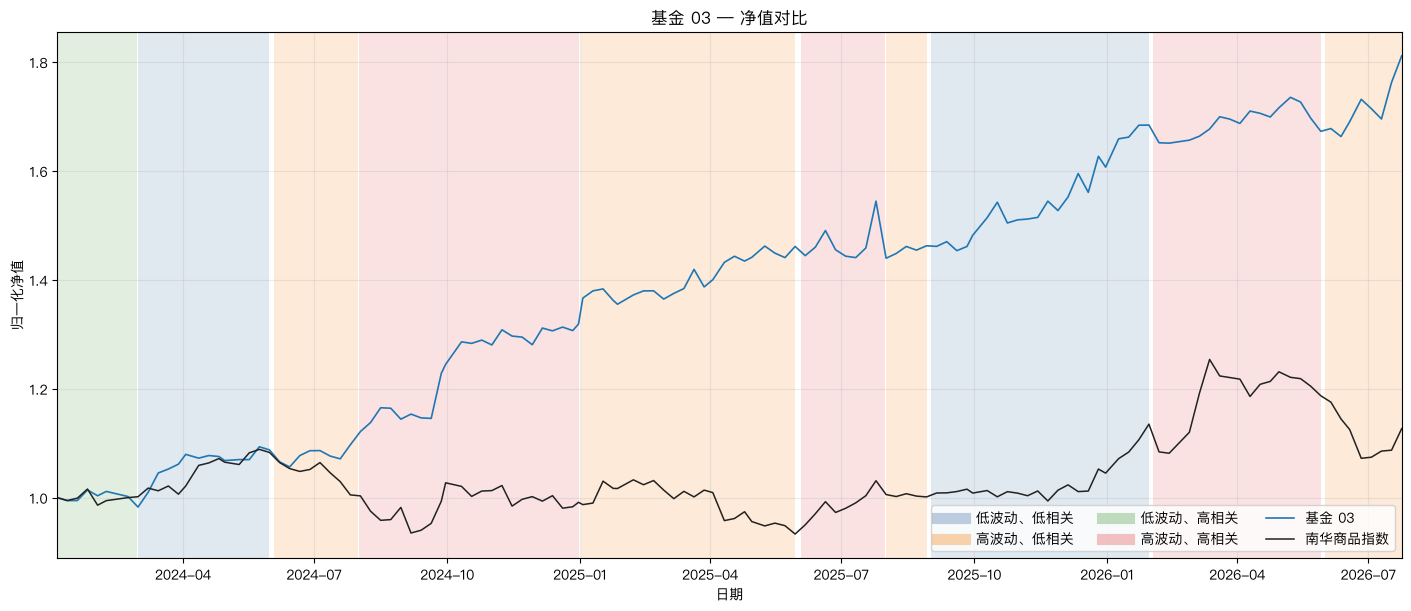

,南华商品指数 年化收益,南华商品指数 夏普,基金 03 年化收益,基金 03 夏普
低波动、低相关,34.48%,3.07,38.03%,2.85
高波动、低相关,-23.07%,-2.02,17.89%,1.32
低波动、高相关,-0.07%,0.04,1.75%,0.24
高波动、高相关,15.60%,0.95,29.36%,2.05


### 基金 06

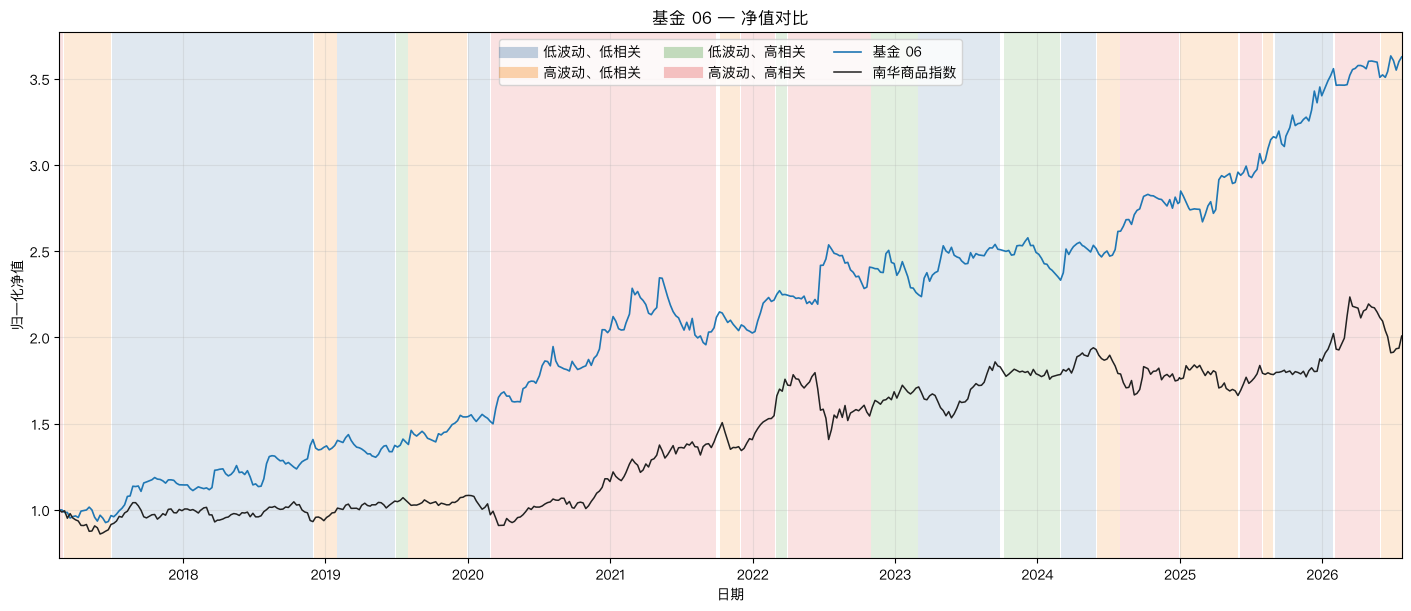

,南华商品指数 年化收益,南华商品指数 夏普,基金 06 年化收益,基金 06 夏普
低波动、低相关,7.99%,0.68,22.17%,1.54
高波动、低相关,-12.61%,-0.95,9.25%,0.74
低波动、高相关,28.37%,1.87,-11.22%,-1.03
高波动、高相关,16.19%,0.95,18.73%,1.23


,fund,category,status,start_date,end_date,observations
0,基金 02,截面,included,2019-07-29,2026-07-31,394
1,基金 04,截面,included,2017-03-01,2026-07-31,1605
2,基金 05,截面,included,2023-01-05,2026-07-24,199
3,基金 01,趋势,included,2025-04-22,2026-07-31,311
4,基金 03,趋势,included,2024-01-05,2026-07-24,133
5,基金 06,趋势,included,2017-02-17,2026-07-24,484


In [3]:
overlap_records = []
category_titles = {"截面": "## 截面类产品", "趋势": "## 趋势类产品"}
for category, category_funds in fund_categories.items():
    display(Markdown(category_titles[category]))
    for fund_name in category_funds:
        if fund_name not in funds.nav:
            continue
        display(Markdown(f"### {fund_name}"))
        aligned = pd.concat([funds.nav[fund_name], context.nhci.rename("NHCI")], axis=1, sort=True).dropna()
        aligned = aligned.loc[aligned.gt(0).all(axis=1)]
        if len(aligned) < 2:
            overlap_records.append({"fund": fund_name, "category": category, "status": "excluded", "reason": "不足两个共同观测"})
            continue
        figure = plot_fund_vs_nhci(funds.nav[fund_name], context.nhci, context.stages, fund_name)
        fund_number = fund_name.split()[-1]
        figure_path = FIGURES_DIR / f"figure_{int(fund_number) + 4}_fund_{fund_number}.png"
        figure.savefig(figure_path, dpi=150, bbox_inches="tight")
        display(figure)
        plt.close(figure)
        metrics = compute_regime_annualized_returns(aligned[["NHCI", fund_name]], context.daily_regimes)
        nhci_metrics = metrics.xs("NHCI", level="series")
        fund_metrics = metrics.xs(fund_name, level="series")
        table = pd.concat(
            [
                nhci_metrics[["annualized_return", "annualized_sharpe"]],
                fund_metrics[["annualized_return", "annualized_sharpe"]],
            ],
            axis=1,
        )
        table = table.reindex(["LV_LC", "HV_LC", "LV_HC", "HV_HC"])
        table.index = [REGIME_LABELS[regime] for regime in table.index]
        table.columns = ["南华商品指数 年化收益", "南华商品指数 夏普", f"{fund_name} 年化收益", f"{fund_name} 夏普"]
        formats = {
            "南华商品指数 年化收益": "{:.2%}",
            "南华商品指数 夏普": "{:.2f}",
            f"{fund_name} 年化收益": "{:.2%}",
            f"{fund_name} 夏普": "{:.2f}",
        }
        display(table.style.format(formats))
        overlap_records.append(
            {
                "fund": fund_name,
                "category": category,
                "status": "included",
                "start_date": aligned.index.min(),
                "end_date": aligned.index.max(),
                "observations": len(aligned),
            }
        )
overlaps = pd.DataFrame(overlap_records)
display(overlaps)

In [4]:
display(
    HTML(
        "<details><summary>基金文件与共同区间诊断</summary>"
        + funds.manifest.to_html(index=False)
        + overlaps.to_html(index=False)
        + "</details>"
    )
)